## Course: INFO-6147 Deep Learning with PyTorch
* Place365 Images Clasification Project
* Author: Marvin - Longfei Li
* Date: April 3, 2026

## Introduction

Place365 mini hard dataset


## Initialize environment

In [1]:
import os
# Solve the problem of libraries conflict.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")

# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import io
import torch
from torch import nn
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset
import torchvision.utils as vutils
import numpy as np
import torchvision

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Check the number of GPUs
gpu_num = 0
if device.type == 'cuda':
    gpu_num = torch.cuda.device_count()
print(f"Number of GPUs available: {gpu_num}")

# Set random seeds
random_seed = 52
torch.manual_seed(random_seed)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(random_seed)
torch.use_deterministic_algorithms(True)

# Define class names for the 10 classes
class_names = [
    'Boxing Stage',      # 0
    'Inside a Car',      # 1
    'Airplane Cockpit',  # 2
    'Forest',            # 3
    'Outside a Car',     # 4
    'Conference Room',   # 5
    'Rehearsal Room',    # 6
    'Stage',             # 7
    'Performance',       # 8
    'Conference Hall',  # 9
]

# Define batch size
batch_size = 32

Using device: cuda
Number of GPUs available: 1


## Loading Dataset

+ 0 Boxing Stage
+ 1 Inside a Car
+ 2 Airplane Cockpit
+ 3 Forest
+ 4 Outside a Car
+ 5 Conference Room
+ 6 Rehearsal Room
+ 7 Stage
+ 8 Performance
+ 9 Conference Hall

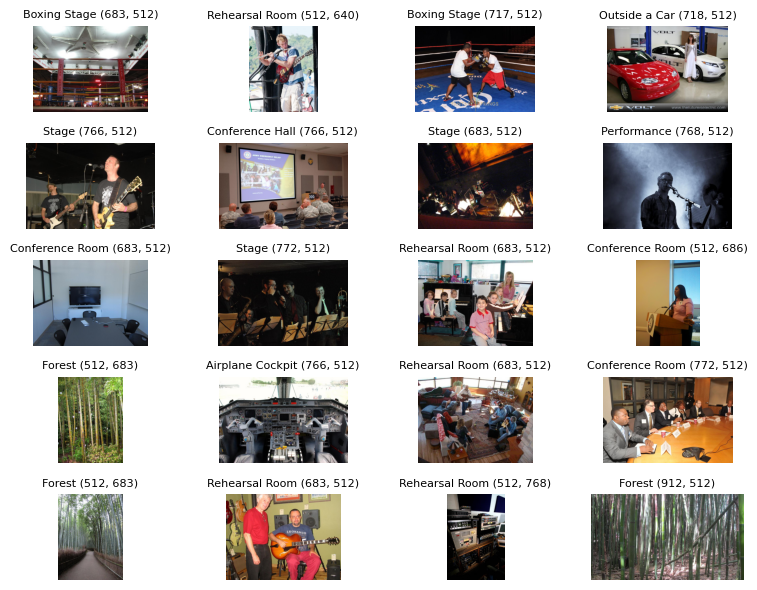

In [2]:
df_train = pd.read_parquet("./data/places365-mini-sample-hard-train.parquet")
df_test = pd.read_parquet("./data/places365-mini-sample-hard-test.parquet")

def show_first_images(df, count=20):
    fig, axes = plt.subplots(5, 4, figsize=(8, 6))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, df.head(count).iterrows()):
        image_bytes = row["image"]["bytes"]
        label = row["label"]
        image = Image.open(io.BytesIO(image_bytes))
        ax.imshow(image)
        ax.set_title(f"{class_names[label]} {image.size}", fontsize=8)
        ax.axis("off")

    # plt.title("First 20 Images from Original Training Set")
    plt.tight_layout()
    plt.show()

show_first_images(df_train)

## Preprossing Dataset

Training batches: 219 Validation batches: 16
Testing batches: 16


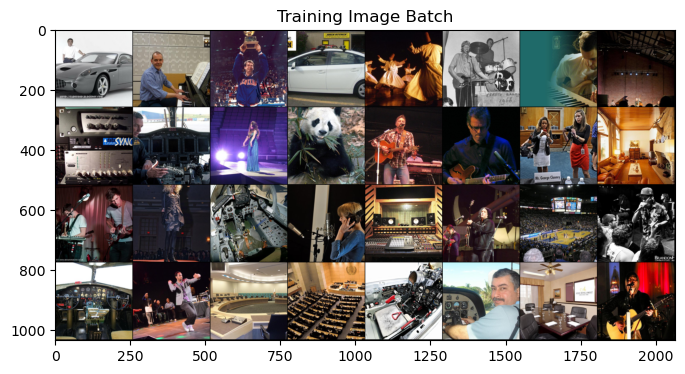

In [3]:
class PlacesDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        self.image_bytes = df["image"].apply(lambda x: x["bytes"]).tolist()
        self.labels = df["label"].tolist()
        self.transform = transform
        self.resized_images = [None] * len(self.labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        if self.resized_images[idx] is not None:
            return self.resized_images[idx], self.labels[idx]
        image = Image.open(io.BytesIO(self.image_bytes[idx])).convert("RGB")
        self.resized_images[idx] = self.transform(image)
        return self.resized_images[idx], self.labels[idx]

if os.path.exists("./data/train_loader.pt") and os.path.exists("./data/test_loader.pt"):
    train_loader = torch.load("./data/train_loader.pt", weights_only=False)
    test_loader = torch.load("./data/test_loader.pt", weights_only=False)

else:
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    train_dataset = PlacesDataset(df_train, transform=transform)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    train_loader = list(train_loader)
    torch.save(train_loader, './data/train_loader.pt')

    test_dataset = PlacesDataset(df_test, transform=transform)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    test_loader = list(test_loader)
    torch.save(test_loader, './data/test_loader.pt')

train_data = train_loader[:219]
val_data = train_loader[219:]
print(f"Training batches: {len(train_data)} Validation batches: {len(val_data)}")
test_data = test_loader
print(f"Testing batches: {len(test_loader)}")

image_batch = next(iter(train_loader))
plt.figure(figsize=(8,8))
plt.title("Training Image Batch")
plt.imshow(np.transpose(vutils.make_grid(image_batch[0].to(device)[:batch_size], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()


## Defining LeNet Model

In [ ]:
class LeNet(nn.Module):
    # According to the experiment, the Tanh and Sigmoid activation functions perform worse than ReLU, the gradients were vanished.
    def __init__(self, ngpu, num_classes=10):
        super(LeNet, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5, padding=2), # 3 * 256 * 256 -> 6 * 256 * 256
            nn.ReLU(),
            nn.AvgPool2d(2, 2),             # 6 * 256 * 256 -> 6 * 128 * 128
            
            nn.Conv2d(6, 16, kernel_size=5, padding=2), # 6 * 128 * 128 -> 16 * 128 * 128
            nn.ReLU(),
            nn.AvgPool2d(2, 2),             # 16 * 128 * 128 -> 16 * 64 * 64
            
            nn.Flatten(),
            nn.Linear(16 * 64 * 64, 120), # 16 * 64 * 64 -> 120
            nn.ReLU(),
            nn.Linear(120, 84), # 120 -> 84
            nn.ReLU(),
            nn.Linear(84, num_classes) # 84 -> 10
        )
    def forward(self, x):
        return self.main(x)
    
model = LeNet(gpu_num).to(device)

if (device.type == 'cuda') and (gpu_num > 1):
    model = nn.DataParallel(model, list(range(gpu_num)))
    
# Generate TensorBoard graph
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("./runs")
dummy_input = torch.randn(1, 3, 256, 256).to(device)
writer.add_graph(model, dummy_input)
writer.close()

from torchinfo import summary
summary(model, input_size=(batch_size, 3, 256, 256), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
LeNet                                    [32, 10]                  --
├─Sequential: 1-1                        [32, 10]                  --
│    └─Conv2d: 2-1                       [32, 6, 256, 256]         456
│    └─ReLU: 2-2                         [32, 6, 256, 256]         --
│    └─AvgPool2d: 2-3                    [32, 6, 128, 128]         --
│    └─Conv2d: 2-4                       [32, 16, 128, 128]        2,416
│    └─ReLU: 2-5                         [32, 16, 128, 128]        --
│    └─AvgPool2d: 2-6                    [32, 16, 64, 64]          --
│    └─Flatten: 2-7                      [32, 65536]               --
│    └─Linear: 2-8                       [32, 120]                 7,864,440
│    └─ReLU: 2-9                         [32, 120]                 --
│    └─Linear: 2-10                      [32, 84]                  10,164
│    └─ReLU: 2-11                        [32, 84]                  --


## Training

In [5]:
import torch.optim as optim
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in tqdm(range(20)):  # loop over the dataset multiple times

    model.train()
    train_correct = 0
    train_total = 0
    total_count = 0
    for item, data in enumerate(train_data, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss = loss.item()

        # calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        total_count += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        train_accuracy = train_correct / train_total

        # accumulate training statistics (loss & accuracy) every 9 iterations, the total quantity keeps the same as the validation data.
        if total_count / (batch_size * 13) >= 1.0:
            train_losses.append(train_loss)
            train_accuracies.append(train_accuracy)
            # print(f'Training Index {item}, Loss: {train_loss:.4f}, Accuracy: {train_correct}/{train_total}')
            total_count = total_count % (batch_size * 13)
    print(f'Training Epoch [{epoch}], Loss: {train_loss:.4f}, Accuracy: {train_accuracy * 100:.4f}%')

    # Validation at the end of the epoch
    # set mode to eval mode & tell torch no gradients are required.
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        # loop through the data and find accuracy and loss for all val data
        for item, data in enumerate(val_data, 0):
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            val_loss = loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            val_accuracy = val_correct / val_total

            val_losses.append(val_loss)
            val_accuracies.append(val_accuracy)
        print(f'Validation Epoch [{epoch}], Loss: {val_loss:.4f}, Accuracy: {val_accuracy * 100:.4f}%')


print('Finished Training')
torch.save(model.state_dict(), './data/le_net.pth')

  0%|          | 0/20 [00:00<?, ?it/s]

Training Epoch [0], Loss: 1.5016, Accuracy: 35.2312%


  5%|▌         | 1/20 [00:10<03:14, 10.26s/it]

Validation Epoch [0], Loss: 1.3307, Accuracy: 43.6992%
Training Epoch [1], Loss: 1.2784, Accuracy: 48.4161%


 10%|█         | 2/20 [00:17<02:27,  8.20s/it]

...

Validation Epoch [17], Loss: 6.7373, Accuracy: 42.6829%
Training Epoch [18], Loss: 0.0003, Accuracy: 99.2865%


 95%|█████████▌| 19/20 [02:10<00:06,  6.65s/it]

Validation Epoch [18], Loss: 8.2202, Accuracy: 44.7154%
Training Epoch [19], Loss: 0.0002, Accuracy: 99.6718%


100%|██████████| 20/20 [02:16<00:00,  6.83s/it]

Validation Epoch [19], Loss: 7.3042, Accuracy: 44.5122%
Finished Training


## Loading trained model

In [6]:
# model = LeNet(gpu_num).to(device)
# model.load_state_dict(torch.load('./data/le_net.pth', map_location=device))
# model.eval()


## Evaluation and Visualization on Training and Validation Datasets

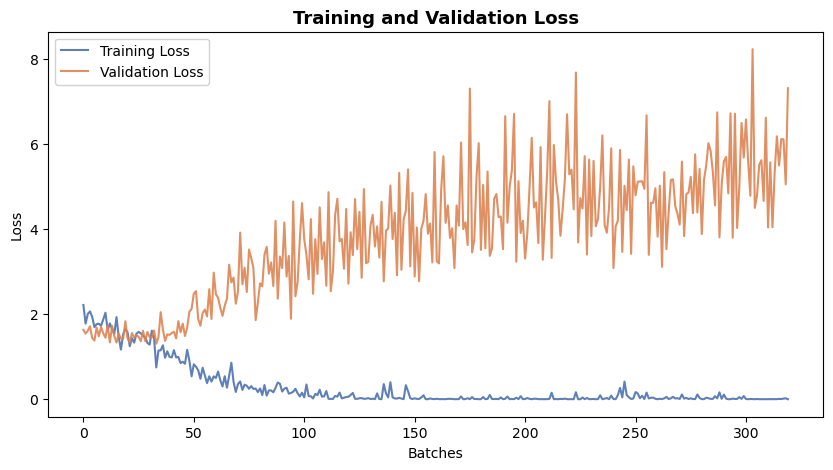

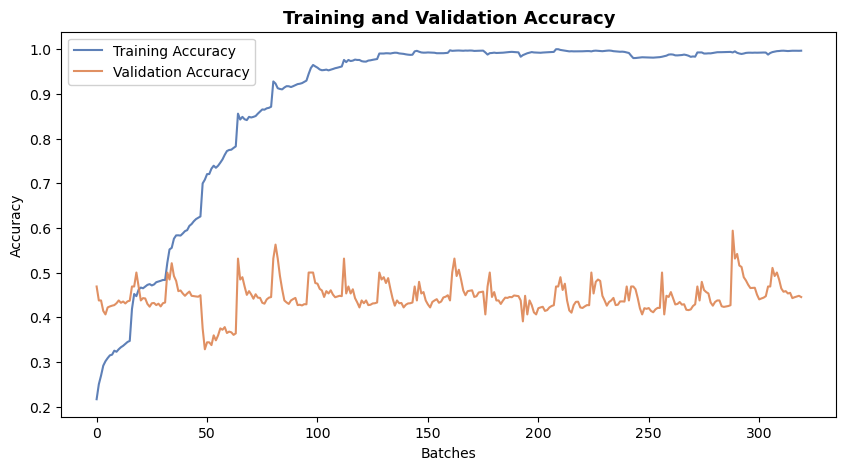

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='#4C72B0', linewidth=1.5, alpha=0.9)
plt.plot(val_losses, label='Validation Loss', color='#DD8452', linewidth=1.5, alpha=0.9)
plt.title('Training and Validation Loss',  fontsize=13, fontweight='bold')
plt.xlabel('Batches')
plt.ylabel('Loss')
plt.legend(framealpha=0.9); plt.tick_params(labelsize=10)

plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Training Accuracy', color='#4C72B0', linewidth=1.5, alpha=0.9)
plt.plot(val_accuracies, label='Validation Accuracy', color='#DD8452', linewidth=1.5, alpha=0.9)
plt.title('Training and Validation Accuracy', fontsize=13, fontweight='bold')
plt.xlabel('Batches')
plt.ylabel('Accuracy')
plt.legend(framealpha=0.9); plt.tick_params(labelsize=10)

## Confusion Matrix on Test Set

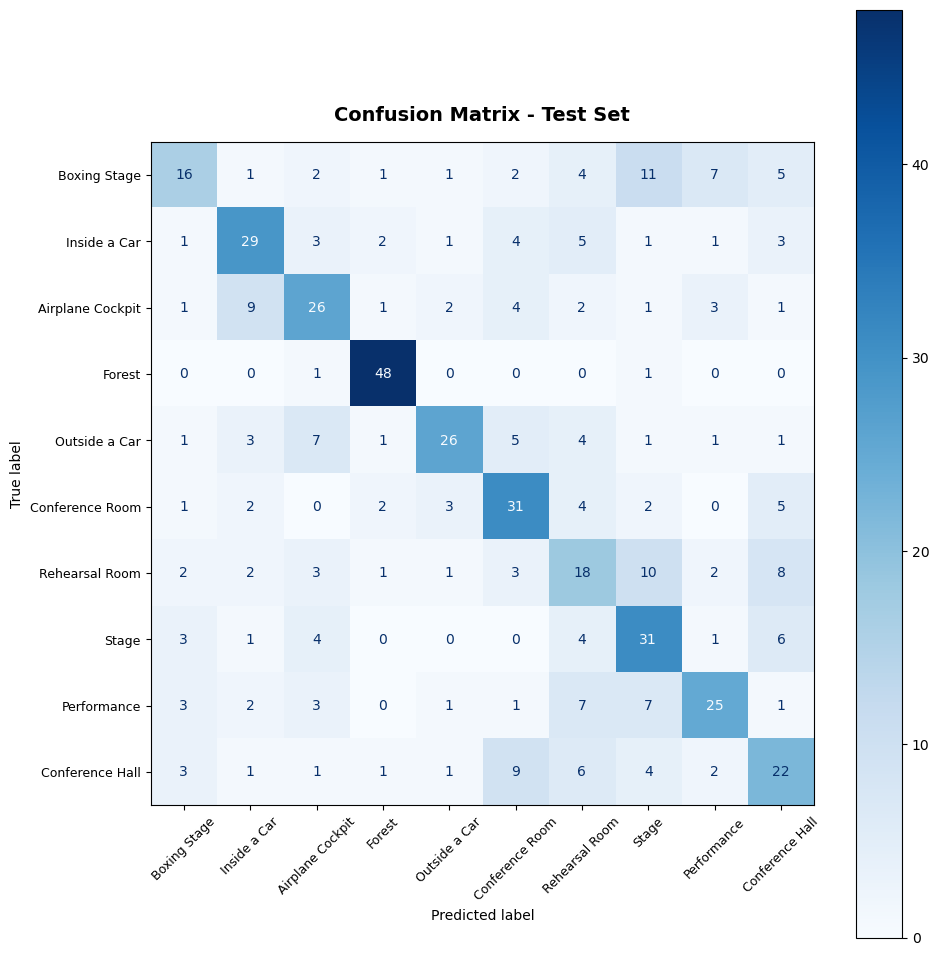

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_data:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
# for item in zip(all_labels, all_preds):
#     print(f"Predicted: {item[1]}, Actual: {item[0]}")

def show_confusion_matrix(cm):
    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45, colorbar=True)
    ax.set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold', pad=15)
    ax.tick_params(axis='both', labelsize=9)
    plt.tight_layout()
    plt.show()

show_confusion_matrix(cm)

## F1 Scores Calculation

Per-class F1: [0.39506173 0.58       0.52       0.89719626 0.60465116 0.56880734
 0.34615385 0.5210084  0.54347826 0.43137255]
Weighted F1: 0.5408

Classification Report:
                  precision    recall  f1-score   support

    Boxing Stage       0.52      0.32      0.40        50
    Inside a Car       0.58      0.58      0.58        50
Airplane Cockpit       0.52      0.52      0.52        50
          Forest       0.84      0.96      0.90        50
   Outside a Car       0.72      0.52      0.60        50
 Conference Room       0.53      0.62      0.57        50
  Rehearsal Room       0.33      0.36      0.35        50
           Stage       0.45      0.62      0.52        50
     Performance       0.60      0.50      0.54        50
 Conference Hall       0.42      0.44      0.43        50

        accuracy                           0.54       500
       macro avg       0.55      0.54      0.54       500
    weighted avg       0.55      0.54      0.54       500



C:\Users\dtlon\AppData\Local\Temp\ipykernel_34548\3652789241.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)


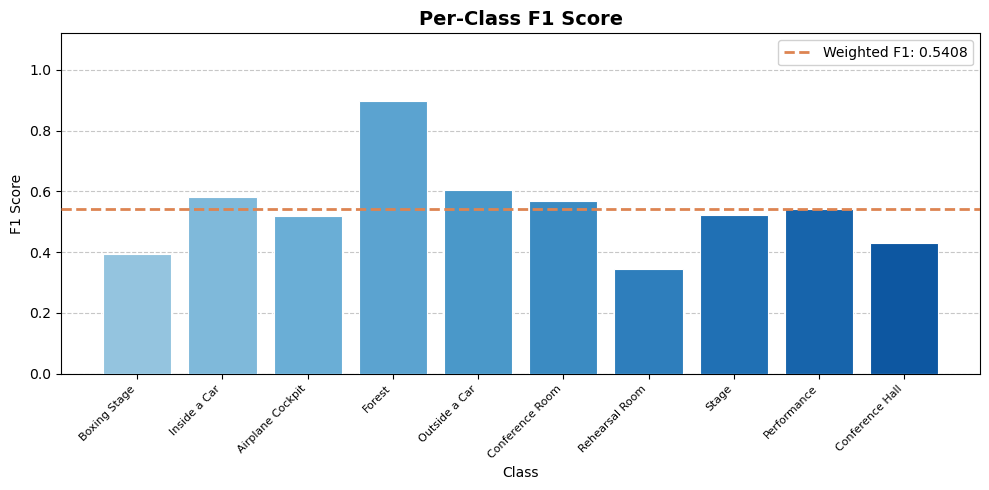

In [9]:
from sklearn.metrics import f1_score, classification_report

# Per-class F1 scores
f1_per_class = f1_score(all_labels, all_preds, average=None)
f1_weighted = f1_score(all_labels, all_preds, average='weighted')

print(f"Per-class F1: {f1_per_class}")
print(f"Weighted F1: {f1_weighted:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Bar chart visualization
def show_f1_bar_chart(f1_per_class, f1_weighted):
    palette = plt.cm.Blues(np.linspace(0.4, 0.85, len(class_names)))
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(class_names, f1_per_class, color=palette, edgecolor='white', linewidth=0.8, zorder=3) # Each
    ax.axhline(y=f1_weighted, color='#DD8452', linewidth=2, linestyle='--', label=f'Weighted F1: {f1_weighted:.4f}', zorder=4) # Average

    ax.set_ylim(0, 1.12)
    ax.set_xlabel('Class', fontsize=10)
    ax.set_ylabel('F1 Score', fontsize=10)
    ax.set_title('Per-Class F1 Score', fontsize=14, fontweight='bold')
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

show_f1_bar_chart(f1_per_class, f1_weighted)